In [1]:
#imports 
import pyfar as pf 
import matplotlib as mpl
import matplotlib.pyplot as plt 
#from playaudio import playaudio
import numpy as np
import sounddevice as sd
import scipy 

In [20]:
#path
hrtf_path = 'dataset\P0001'
hrtf_name = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_FreeFieldCompMinPhase_NoITD_48kHz.sofa'

audio='dataset/dataset/audio/wassim perc.wav'
sinewave = 'dataset/dataset/audio/sinewave.wav'

In [12]:
# Hrtf visualisation
data_ir, source_coordinates, receiver_coordinates = pf.io.read_sofa(hrtf_name)


SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel


<Axes3D: xlabel='x in m', ylabel='y in m', zlabel='z in m'>

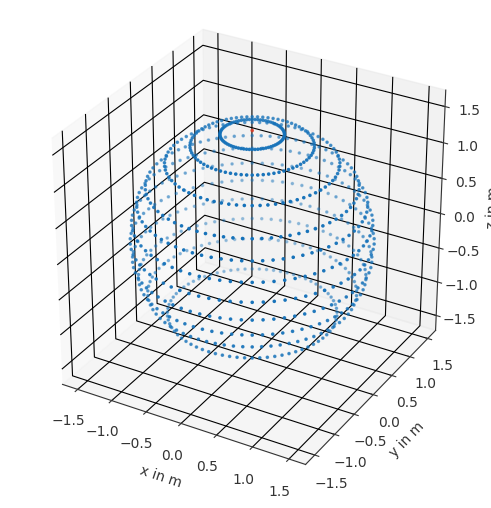

In [13]:
target_point = pf.Coordinates.from_spherical_elevation(np.pi, np.pi/2, 1.5)
index, *_ = source_coordinates.find_nearest(target_point,k=1)
source_coordinates.show(index)

In [14]:
sliced_coord = source_coordinates[source_coordinates.azimuth == np.pi/2]
sliced_coord.show()

<Axes3D: xlabel='x in m', ylabel='y in m', zlabel='z in m'>

In [15]:
# plotting 
pf.plot.time_freq(data_ir[index])

array([<Axes: xlabel='Time in s', ylabel='Amplitude'>,
       <Axes: xlabel='Frequency in Hz', ylabel='Magnitude in dB'>],
      dtype=object)

In [25]:
# play audio 
sd.play(data_ir[index].time.T, data_ir.sampling_rate)

sd.wait()

In [26]:
# original audio 
sr, x= scipy.io.wavfile.read(audio)
x = x.astype(np.float32) / np.max(np.abs(x))
x_left = x[:,0]

sd.play(x_left, data_ir.sampling_rate)



In [27]:
impulse_left= data_ir.time[index[0],0]
impulse_right= data_ir.time[index[0],1]

#load audio 
sr, x= scipy.io.wavfile.read(audio)
x = x.astype(np.float32) / np.max(np.abs(x))
x_mono = np.mean(x, axis=1) 

#convolution
spatial_audio_left = np.convolve(impulse_left,x_mono)
spatial_audio_right = np.convolve(impulse_right,x_mono)

spatial_audio = np.column_stack((spatial_audio_left, spatial_audio_right))


sd.play(spatial_audio, data_ir.sampling_rate)

sd.wait()